<a href="https://colab.research.google.com/github/eliseis/gbjhtygjhnfvbngfthyj/blob/main/word2vec_sgns_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec (SGNS)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import zipfile
import urllib.request
from collections import Counter
from pathlib import Path

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Hyperparameters (Standard SGNS defaults)  as in OG papers
EMBEDDING_DIM = 100
WINDOW_SIZE = 5
NUM_NEGATIVES = 5
BATCH_SIZE = 4096
EPOCHS = 3
LEARNING_RATE = 0.025 * BATCH_SIZE # Scaled for Mean Loss (0.025 * 4096 ~ 100)
MIN_COUNT = 5
SUBSAMPLE_THRESHOLD = 1e-5
NOISE_POWER = 0.75

from IPython.display import clear_output


Configuration: Dim=100, Window=5, Negs=5, Batch=4096, LR=102.4


## 2. Vocabulary & Data Processing
The `Vocabulary` class handles:
1. **Tokenization & Counting**: Building the frequency table.
2. **Subsampling**: Frequent words (like "the", "and") are probabilistically dropped to improve training speed and quality of rare word vectors.
   $$ P(keep) = 1 - \sqrt{\frac{t}{f(w)}} $$
3. **Noise Distribution**: For negative sampling, we draw from the unigram distribution raised to the power 0.75.
   $$ P_n(w) \propto U(w)^{0.75} $$


In [2]:
class Vocabulary:
    def __init__(self, min_count=5, subsample_threshold=1e-5, noise_power=0.75):
        self.min_count = min_count
        self.subsample_threshold = subsample_threshold
        self.noise_power = noise_power
        self.word2idx = {}
        self.idx2word = []
        self.subsample_probs = np.array([])
        self.noise_distribution = np.array([])

    @property
    def size(self):
        return len(self.idx2word)

    def build(self, tokens):
        raw_counts = Counter(tokens)
        total_words = sum(raw_counts.values())

        filtered = sorted(
            ((w, c) for w, c in raw_counts.items() if c >= self.min_count),
            key=lambda x: -x[1]
        )

        self.idx2word = [w for w, _ in filtered]
        self.word2idx = {w: i for i, w in enumerate(self.idx2word)}
        counts = np.array([c for _, c in filtered], dtype=np.float64)

        freq = counts / total_words
        self.subsample_probs = 1.0 - np.sqrt(self.subsample_threshold / (freq + 1e-12))
        self.subsample_probs = np.clip(self.subsample_probs, 0.0, 1.0)

        noise = counts ** self.noise_power
        self.noise_distribution = noise / noise.sum()
        return self

    def encode(self, tokens):
        return np.array([self.word2idx[t] for t in tokens if t in self.word2idx], dtype=np.int64)

    def subsample_mask(self, indices, rng):
        discard_probs = self.subsample_probs[indices]
        return rng.random(len(indices)) >= discard_probs

    def sample_negatives(self, count, rng):
        return rng.choice(len(self.idx2word), size=count, replace=True, p=self.noise_distribution)


In [3]:
def load_text8():
    url = "http://mattmahoney.net/dc/text8.zip"
    path = Path("data/text8")
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print("Downloading text8...")
        zip_path = path.parent / "text8.zip"
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extract("text8", path.parent)
        zip_path.unlink()
    with open(path, "r") as f:
        return f.read().split()

def batch_generator(corpus_indices, vocab, window_size, batch_size, num_negatives, rng):

    keep_mask = vocab.subsample_mask(corpus_indices, rng)
    filtered_corpus = corpus_indices[keep_mask]
    n = len(filtered_corpus)

    c_buffer, ctx_buffer = [], []

    for i in range(n):
        actual_window = rng.integers(1, window_size + 1)
        start = max(0, i - actual_window)
        end = min(n, i + actual_window + 1)

        c = filtered_corpus[i]
        for j in range(start, end):
            if i != j:
                c_buffer.append(c)
                ctx_buffer.append(filtered_corpus[j])

                if len(c_buffer) >= batch_size:
                    c_batch = np.array(c_buffer)
                    ctx_batch = np.array(ctx_buffer)

                    neg_batch = vocab.sample_negatives(len(c_batch) * num_negatives, rng).reshape(len(c_batch), num_negatives)

                    while True:
                        mask = neg_batch == ctx_batch[:, np.newaxis]
                        if not np.any(mask): break
                        neg_batch[mask] = vocab.sample_negatives(mask.sum(), rng)

                    yield c_batch, ctx_batch, neg_batch
                    c_buffer, ctx_buffer = [], []

    if c_buffer:
        c_batch = np.array(c_buffer)
        ctx_batch = np.array(ctx_buffer)
        neg_batch = vocab.sample_negatives(len(c_batch) * num_negatives, rng).reshape(len(c_batch), num_negatives)
        while True:
            mask = neg_batch == ctx_batch[:, np.newaxis]
            if not np.any(mask): break
            neg_batch[mask] = vocab.sample_negatives(mask.sum(), rng)
        yield c_batch, ctx_batch, neg_batch


## 3. Model Architecture (SGNS)

### Forward Pass (Loss)
For a batch of center words $c$, context words $o$, and negative samples $n_{1..K}$, the loss is:
$$ J = - \frac{1}{B} \sum_{i=1}^B \left( \log \sigma(\mathbf{u}_{o_i}^\top \mathbf{v}_{c_i}) + \sum_{k=1}^K \log \sigma(-\mathbf{u}_{n_{ik}}^\top \mathbf{v}_{c_i}) \right) $$

### Vectorization Strategy
NumPy broadcasting:
- `centers`: $(B,)$
- `contexts`: $(B,)$
- `negatives`: $(B, K)$
- `v_center`: $(B, D)$
- `u_negative`: $(B, K, D)$


In [4]:
class Word2VecSGNS:
    def __init__(self, vocab_size, embedding_dim, seed=42):
        self.V = vocab_size
        self.D = embedding_dim
        self.rng = np.random.default_rng(seed)

        # Initialization (Original Word2Vec)
        # W_in: Uniform(-0.5/dim, 0.5/dim)
        # W_out: Zeros
        self.W_in = (self.rng.random((vocab_size, embedding_dim)) - 0.5) / embedding_dim
        self.W_out = np.zeros((vocab_size, embedding_dim))
        self._cache = None

    @staticmethod
    def _sigmoid(x):
        out = np.empty_like(x, dtype=np.float64)
        pos = x >= 0
        out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
        exp_x = np.exp(x[~pos])
        out[~pos] = exp_x / (1.0 + exp_x)
        return out

    def forward(self, centers, contexts, negatives):

        B = len(centers)
        K = negatives.shape[1]

        # 1. Lookup Embeddings
        # v_center: (B, D)
        v_center = self.W_in[centers]
        # u_context: (B, D)
        u_context = self.W_out[contexts]
        # u_negative: (B, K, D)
        u_negative = self.W_out[negatives]

        # 2. Positive Scores: (B,)
        # Dot product: sum(v * u, axis=1)
        pos_score = np.sum(v_center * u_context, axis=1)
        pos_sigmoid = self._sigmoid(pos_score)

        # 3. Negative Scores: (B, K)
        # Batch dot product: (B, D) vs (B, K, D) -> (B, K)
        neg_scores = np.einsum('bd,bkd->bk', v_center, u_negative)
        neg_sigmoid = self._sigmoid(-neg_scores)

        # 4. Loss Computation
        # Small epsilon to avoid log(0)
        eps = 1e-12
        loss = -(np.sum(np.log(pos_sigmoid + eps)) + np.sum(np.log(neg_sigmoid + eps))) / B

        # Cache for backward pass
        self._cache = (centers, contexts, negatives, v_center, u_context, u_negative, pos_sigmoid, neg_sigmoid)
        return loss

    def backward(self):
        """Compute Gradients."""
        centers, contexts, negatives, v_center, u_context, u_negative, pos_sigmoid, neg_sigmoid = self._cache
        B, K = negatives.shape

        # --- Gradients w.r.t scores ---
        # dL/d(pos_score) = sigma(pos_score) - 1
        # Shape: (B, 1) for broadcasting
        d_pos_score = (pos_sigmoid - 1.0)[:, np.newaxis]

        # dL/d(neg_score) = sigma(neg_score) = 1 - neg_sigmoid
        # Shape: (B, K, 1) for broadcasting
        d_neg_score = (1.0 - neg_sigmoid)[:, :, np.newaxis]

        # --- Gradients w.r.t embeddings ---

        # 1. Output (Context) Gradients
        # dL/d(u_context) = d_pos_score * v_center
        d_u_context = d_pos_score * v_center  # (B, D)

        # 2. Output (Negative) Gradients
        # dL/d(u_negative) = d_neg_score * v_center
        # (B, K, 1) * (B, 1, D) -> (B, K, D)
        d_u_negative = d_neg_score * v_center[:, np.newaxis, :]

        # 3. Input (Center) Gradients
        # Contribution from positive: d_pos_score * u_context
        d_v_center = d_pos_score * u_context # (B, D)

        # Contribution from negatives: sum_over_k(d_neg_score * u_negative)
        # (B, K, 1) * (B, K, D) -> (B, K, D) -> sum -> (B, D)
        d_v_center += np.sum(d_neg_score * u_negative, axis=1)


        d_v_center /= B
        d_u_context /= B
        d_u_negative /= B
        return d_v_center, d_u_context, d_u_negative

    def update(self, lr):
        """Sparse Parameter Update"""
        d_v_c, d_u_ctx, d_u_neg = self.backward()
        centers, contexts, negatives = self._cache[0], self._cache[1], self._cache[2]

        # In-place sparse updates using np.subtract.at
        # We use MEAN gradients (d_loss/d_params). Since we divide by B in backward, we scale LR by B to maintain update magnitude.

        np.subtract.at(self.W_in, centers, lr * d_v_c)
        np.subtract.at(self.W_out, contexts, lr * d_u_ctx)
        np.subtract.at(self.W_out, negatives.ravel(), lr * d_u_neg.reshape(-1, self.D))


## 4. Verification: Numerical Gradient Check
Before running the full training, we must verify that our analytical gradient implementation is correct.
We use the finite difference method:
$$ \frac{df}{dx} \approx \frac{f(x+\epsilon) - f(x-\epsilon)}{2\epsilon} $$
If the difference between our `backward()` gradients and this approximation is small ($< 10^{-4}$), our math is correct.


In [5]:
def numerical_gradient_check():
    print("Running numerical gradient check...")
    V_toy, D_toy = 50, 10
    model = Word2VecSGNS(V_toy, D_toy, seed=1)
    # Perturb W_out slightly for valid gradient check (since it's init to 0)
    model.W_out = np.random.normal(0, 0.1, model.W_out.shape)

    # Create a small toy batch
    B, K = 2, 3
    centers = np.array([0, 1])
    contexts = np.array([2, 3])
    negatives = np.array([[4, 5, 6], [7, 8, 9]])

    # Analytical Gradients
    loss = model.forward(centers, contexts, negatives)
    d_v, d_u_o, d_u_n = model.backward()

    # Input Embedding Gradient (W_in)
    eps = 1e-4
    check_idx, check_dim = 0, 0

    model.W_in[centers[check_idx], check_dim] += eps
    l_plus = model.forward(centers, contexts, negatives)
    model.W_in[centers[check_idx], check_dim] -= eps

    model.W_in[centers[check_idx], check_dim] -= eps
    l_minus = model.forward(centers, contexts, negatives)
    model.W_in[centers[check_idx], check_dim] += eps

    numeric_grad = (l_plus - l_minus) / (2 * eps)
    analytic_grad = d_v[check_idx, check_dim]

    diff = abs(numeric_grad - analytic_grad)
    print(f"  Numerical Grad: {numeric_grad:.8f}")
    print(f"  Analytic Grad : {analytic_grad:.8f}")
    print(f"  Difference    : {diff:.8f}")

    if diff < 1e-5:
        print("Gradient check passed!")
    else:
        print("Gradient check failed!")
        raise ValueError("Gradient check failed")

numerical_gradient_check()


Running numerical gradient check...
  Numerical Grad: -0.02215435
  Analytic Grad : -0.02215435
  Difference    : 0.00000000
Gradient check passed!


## 5. Data Preparation & Model Initialization
We load the `text8` dataset, build the vocabulary, and initialize the model weights.
Crucially, we encode the entire corpus into integers to save memory and speed up batch generation.


In [6]:
# 1. Load Data
print("Loading text8 dataset...")
tokens = load_text8()
print(f"Loaded {len(tokens):,} tokens.")

print(f"First 10 tokens: {tokens[:10]}")

# 2. Build Vocabulary
print("Building vocabulary...")
vocab = Vocabulary(min_count=MIN_COUNT, subsample_threshold=SUBSAMPLE_THRESHOLD, noise_power=NOISE_POWER)
vocab.build(tokens)
print(f"Vocabulary size: {vocab.size:,}")

# 3. Encode Corpus
print("Encoding corpus...")
encoded_corpus = vocab.encode(tokens)
print(f"Encoded corpus length: {len(encoded_corpus):,}")

print(f"First 10 encoded: {encoded_corpus[:10]}")
print(f"Decoded back: {[vocab.idx2word[i] for i in encoded_corpus[:10]]}")

# Free up memory (raw tokens list is huge)
del tokens
import gc
gc.collect()

# 4. Initialize Model
print("Initializing model...")
model = Word2VecSGNS(vocab.size, EMBEDDING_DIM, seed=SEED)
print("Model initialized.")


Loading text8 dataset...
Loaded 17,005,207 tokens.
First 10 tokens: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Building vocabulary...
Vocabulary size: 71,290
Encoding corpus...
Encoded corpus length: 16,718,844
First 10 encoded: [5233 3080   11    5  194    1 3133   45   58  155]
Decoded back: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Initializing model...
Model initialized.


## 6. Training Loop
We now train the model on the text8 dataset.
We use a linear learning rate decay schedule, similar to the original C word2vec implementation.


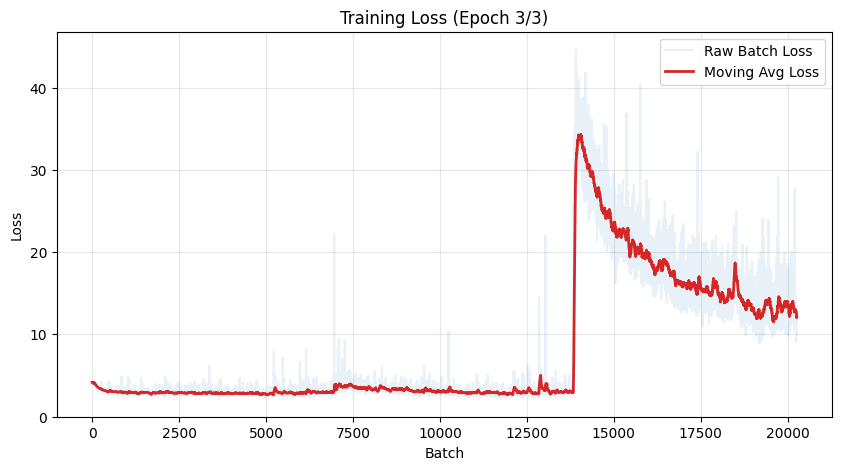

Epoch 3 | Batch 6500 | Loss: 12.3262 | LR: 60.05366

Epoch 3 done. Avg Loss: 17.8845 | Time: 883.9s


In [7]:
losses = []
avg_losses = []

total_pairs = int(len(encoded_corpus) * WINDOW_SIZE * 0.8) * EPOCHS
processed_count = 0
plot_every = 500
window_size = 50

print(f"\nStarting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    epoch_loss = 0
    batch_count = 0
    t0 = time.time()

    for c_batch, ctx_batch, neg_batch in batch_generator(encoded_corpus, vocab, WINDOW_SIZE, BATCH_SIZE, NUM_NEGATIVES, rng):

        lr = LEARNING_RATE * (1.0 - processed_count / total_pairs)
        lr = max(lr, 1e-4)

        loss = model.forward(c_batch, ctx_batch, neg_batch)
        model.update(lr)

        epoch_loss += loss
        batch_count += 1
        processed_count += len(c_batch)
        losses.append(loss)

        if len(losses) >= window_size:
            avg_losses.append(np.mean(losses[-window_size:]))
        else:
            avg_losses.append(loss)

        if batch_count % plot_every == 0:
            clear_output(wait=True)
            plt.figure(figsize=(10, 5))
            plt.plot(losses, alpha=0.1, color='#1f77b4', label='Raw Batch Loss')
            plt.plot(avg_losses, label='Moving Avg Loss', color='#d62728', linewidth=2)
            plt.title(f"Training Loss (Epoch {epoch+1}/{EPOCHS})")
            plt.xlabel("Batch")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            print(f"Epoch {epoch+1} | Batch {batch_count} | Loss: {loss:.4f} | LR: {lr:.5f}")

    avg_loss = epoch_loss / batch_count
    print(f"\nEpoch {epoch+1} done. Avg Loss: {avg_loss:.4f} | Time: {time.time()-t0:.1f}s")


In [8]:
def plot_similarity_heatmap(embeddings, vocab):
    """Plot cosine similarity heatmap for selected words."""
    words = [
        "king", "queen", "prince", "man", "woman",
        "computer", "software", "hardware",
        "france", "germany", "paris", "berlin",
        "cat", "dog", "animal",
    ]
    valid_words = [w for w in words if w in vocab.word2idx]
    if len(valid_words) < 2: return

    n = len(valid_words)

    indices = [vocab.word2idx[w] for w in valid_words]
    vecs = embeddings[indices]
    norms = np.linalg.norm(vecs, axis=1)
    sim_matrix = (vecs @ vecs.T) / (np.outer(norms, norms) + 1e-12)

    plt.figure(figsize=(10, 8))
    plt.imshow(sim_matrix, cmap="RdYlBu_r", vmin=-0.2, vmax=1.0)
    plt.colorbar(label="Cosine Similarity")
    plt.xticks(range(n), valid_words, rotation=45, ha="right")
    plt.yticks(range(n), valid_words)
    plt.title("Word Similarity Heatmap")

    for i in range(n):
        for j in range(n):
            val = sim_matrix[i, j]
            color = "white" if val > 0.5 else "black"
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)
    plt.show()

def plot_semantic_clusters(embeddings, vocab):
    """PCA projection of specific semantic categories."""
    clusters = {
        "Royalty": ["king", "queen", "prince", "royal", "monarch"],
        "Animals": ["cat", "dog", "fish", "bird", "lion", "wolf"],
        "Countries": ["france", "germany", "italy", "russia", "china"],
        "Tech": ["computer", "software", "internet", "code", "data"],
        "Family": ["father", "mother", "son", "daughter", "brother"]
    }

    plt.figure(figsize=(12, 8))
    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

    all_words = []
    for words in clusters.values():
        all_words.extend([w for w in words if w in vocab.word2idx])

    if len(all_words) < 5: return

    indices = [vocab.word2idx[w] for w in all_words]
    X = embeddings[indices]
    X = X - X.mean(axis=0)
    cov = X.T @ X / (len(X) - 1)
    evals, evecs = np.linalg.eigh(cov)
    pca_2d = X @ evecs[:, -2:]

    word_pos_map = {w: i for i, w in enumerate(all_words)}

    for (label, words), color in zip(clusters.items(), colors):
        valid = [w for w in words if w in vocab.word2idx]
        if not valid: continue

        idxs = [word_pos_map[w] for w in valid]
        points = pca_2d[idxs]
        plt.scatter(points[:, 0], points[:, 1], c=color, s=100, label=label, alpha=0.7, edgecolors='w')

        for w, p in zip(valid, points):
            plt.text(p[0]+0.02, p[1]+0.02, w, fontsize=11)

    plt.legend()
    plt.title("Semantic Clusters (PCA)")
    plt.grid(True, alpha=0.3)
    plt.show()


## 6. Evaluation
We evaluate the embeddings using:
1. **Word Similarity**: Finding nearest neighbors.
2. **Analogies**: Solving $A:B :: C:?$.
3. **Visualization**: PCA projection of semantic clusters.


In [11]:
def get_embeddings(model):
    return model.W_in

def most_similar(word, embeddings, vocab, top_k=10):
    if word not in vocab.word2idx:
        print(f"'{word}' not in vocabulary")
        return

    idx = vocab.word2idx[word]
    vec = embeddings[idx]

    norms = np.linalg.norm(embeddings, axis=1)
    vec_norm = np.linalg.norm(vec)
    sims = np.dot(embeddings, vec) / (norms * vec_norm + 1e-10)

    top_idxs = np.argsort(-sims)[:top_k]

    print(f"Nearest to '{word}':")
    for i in top_idxs:
        print(f"  {vocab.idx2word[i]:<15} {sims[i]:.4f}")
    print()

def analogy(a, b, c, embeddings, vocab):
    if any(w not in vocab.word2idx for w in [a, b, c]):
        return

    idx_a, idx_b, idx_c = [vocab.word2idx[w] for w in [a, b, c]]
    vec = embeddings[idx_b] - embeddings[idx_a] + embeddings[idx_c]

    norms = np.linalg.norm(embeddings, axis=1)
    vec_norm = np.linalg.norm(vec)
    sims = np.dot(embeddings, vec) / (norms * vec_norm + 1e-10)

    for idx in [idx_a, idx_b, idx_c]:
        sims[idx] = -1

    top_idx = np.argmax(sims)
    print(f"{a}:{b} :: {c}:{vocab.idx2word[top_idx]} ({sims[top_idx]:.4f})")

emb = get_embeddings(model)

# Test Similarity
most_similar("king", emb, vocab)
most_similar("computer", emb, vocab)

# Test Analogies
analogy("man", "king", "woman", emb, vocab)
analogy("paris", "france", "berlin", emb, vocab)
analogy("good", "better", "bad", emb, vocab)


Nearest to 'king':
  king            1.0000
  son             0.6725
  lord            0.6434
  vii             0.6412
  kings           0.6322
  crown           0.6307
  vi              0.6233
  queen           0.6202
  iii             0.6182
  wales           0.6163

Nearest to 'computer':
  computer        1.0000
  engineering     0.6917
  machines        0.6859
  assisted        0.6784
  science         0.6768
  trivia          0.6650
  machine         0.6559
  pioneers        0.6533
  tasks           0.6504
  directors       0.6494

man:king :: woman:brother (0.6031)
paris:france :: berlin:utilizing (0.7347)
good:better :: bad:toho (0.6464)


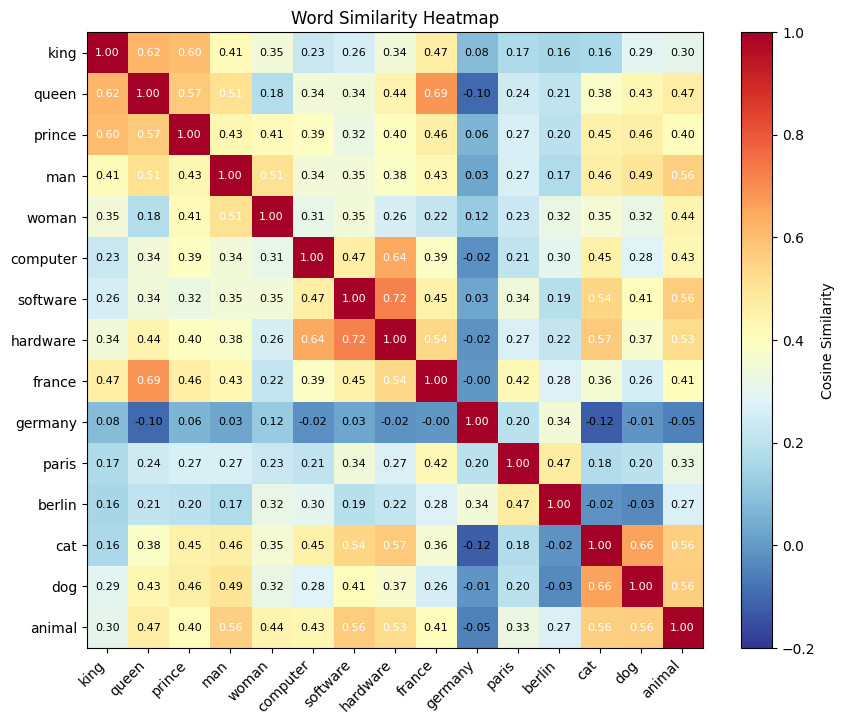

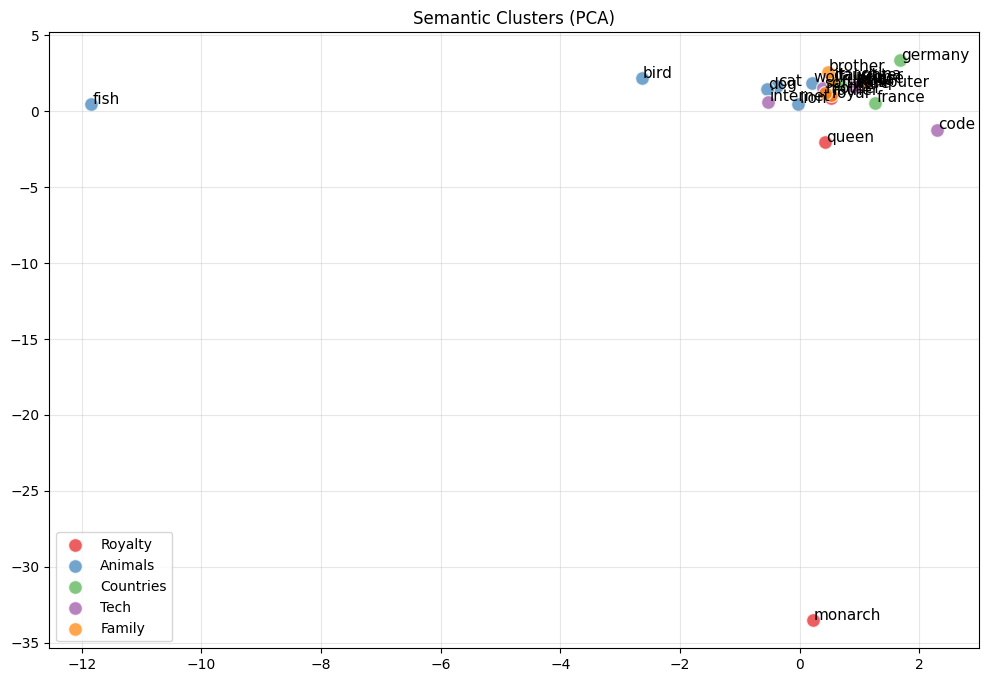

In [10]:
plot_similarity_heatmap(emb, vocab)
plot_semantic_clusters(emb, vocab)
